In [6]:
import tensorflow as tf
x = tf.ones(shape=(2,1))
print(x)

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


In [7]:
x = tf.zeros(shape=(2,1))
print(x)

tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)


In [8]:
x = tf.random.normal(shape=(3,1),mean=0.,stddev=1.)
print(x)
#常態分佈

tf.Tensor(
[[-0.53490466]
 [-0.7600332 ]
 [-1.3850362 ]], shape=(3, 1), dtype=float32)


In [9]:
x = tf.random.uniform(shape=(3,1),minval=0.,maxval=1.)
print(x)
#均勻分佈

tf.Tensor(
[[0.8957397 ]
 [0.65432787]
 [0.85767925]], shape=(3, 1), dtype=float32)


In [10]:
import numpy as np
x = np.ones(shape=(2,2)) #np=numpy陣列，可以賦值(assignment)
x[0,0] = 0

In [11]:
x = tf.ones(shape=(2,2))
x[0,0] = 0 #tf（tensor）不可以賦值

TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

In [12]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3,1))) #區分大小寫，確定其起始值
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.08396594],
       [-1.1944011 ],
       [-0.22370397]], dtype=float32)>


In [13]:
v.assign(tf.ones((3,1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [14]:
v[0,0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [15]:
v.assign_add(tf.ones((3,1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

In [16]:
a = tf.ones((2,2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a,b)
e *= d

In [17]:
input_var = tf.Variable(initial_value=3.)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

In [18]:
input_const = tf.constant(3.)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

In [19]:
time = tf.Variable(0.)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time ** 2
        speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

In [20]:
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0,3],
    cov=[[1, 0.5],[0.5, 1]],
    size = num_samples_per_class
)

positive_samples = np.random.multivariate_normal(
    mean =[3,0],
    cov=[[1,0.5],[0.5,1]],
    size = num_samples_per_class
)

In [21]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                    np.ones((num_samples_per_class, 1),dtype="float32")))

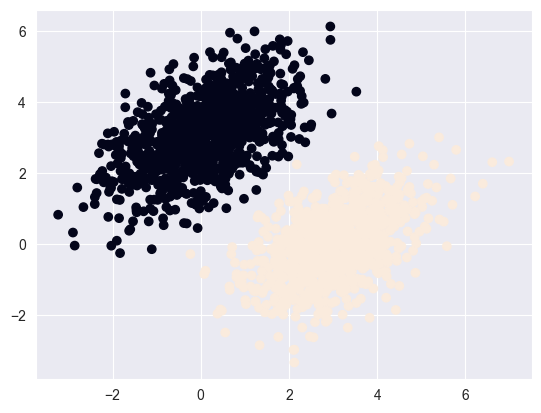

In [22]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0 ], inputs[:,1], c=targets[:,0])
plt.show()

In [23]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))

b = tf.Variable(initial_value=tf.zeros(shape=(output_dim)))

def model(inputs):

    return tf.matmul(inputs, W) + b

def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return  tf.reduce_mean(per_sample_losses)

learning_rate = 0.1

def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(targets, predictions)

    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])

    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [28]:
for step in range(40):
    loss = training_step(inputs, targets)
    print(f"Loss at step {step}:{loss:.4f}")

Loss at step 0:0.0242
Loss at step 1:0.0242
Loss at step 2:0.0242
Loss at step 3:0.0242
Loss at step 4:0.0242
Loss at step 5:0.0242
Loss at step 6:0.0242
Loss at step 7:0.0242
Loss at step 8:0.0242
Loss at step 9:0.0242
Loss at step 10:0.0242
Loss at step 11:0.0242
Loss at step 12:0.0242
Loss at step 13:0.0242
Loss at step 14:0.0242
Loss at step 15:0.0242
Loss at step 16:0.0242
Loss at step 17:0.0242
Loss at step 18:0.0242
Loss at step 19:0.0242
Loss at step 20:0.0242
Loss at step 21:0.0242
Loss at step 22:0.0242
Loss at step 23:0.0242
Loss at step 24:0.0242
Loss at step 25:0.0242
Loss at step 26:0.0242
Loss at step 27:0.0242
Loss at step 28:0.0242
Loss at step 29:0.0242
Loss at step 30:0.0242
Loss at step 31:0.0242
Loss at step 32:0.0242
Loss at step 33:0.0242
Loss at step 34:0.0242
Loss at step 35:0.0242
Loss at step 36:0.0242
Loss at step 37:0.0242
Loss at step 38:0.0242
Loss at step 39:0.0242


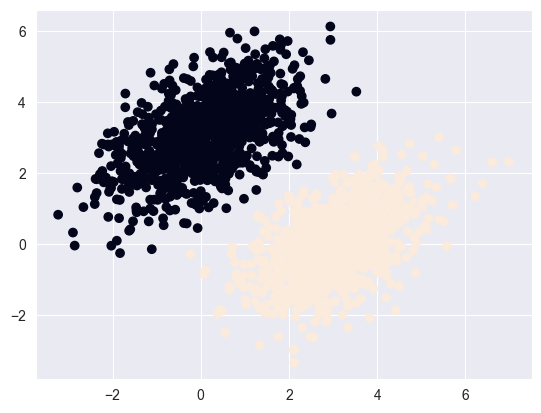

In [29]:
predictions = model(inputs)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:,0] > 0.5)
plt.show()

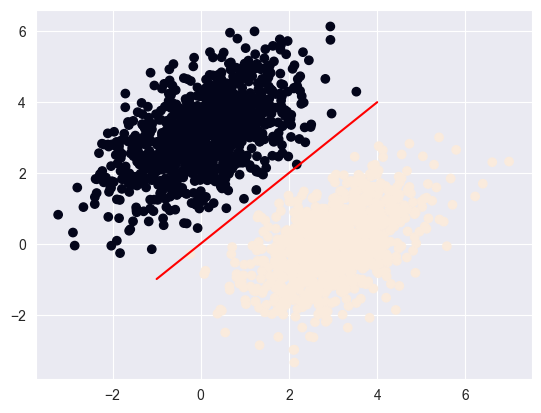

In [30]:
x = np.linspace(-1, 4, 100)
y = - W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:,0] > 0.5)

In [31]:
import keras

class SimpleDense(keras.layers.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.W = self.add_weight(shape=(input_dim, self.units),
                                 initializer="random_normal")
        self.b = self.add_weight(shape=(self.units,),
                                 initializer="zeros")
    def call(self, inputs):
        y = tf.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)

        return y

In [32]:
my_dense = SimpleDense(units=32, activation=tf.nn.relu)

In [33]:
input_tensor = tf.ones(shape=(2, 784))

In [34]:
output_tensor = my_dense(input_tensor)

In [35]:
print(output_tensor.shape)

(2, 32)


In [36]:
from keras import layers
layer = layers.Dense(32, activation="relu")

In [37]:
from keras import models
from keras import layers
models = models.Sequential([layers.Dense(32, activation="relu"),
                            layers.Dense(32)])

In [38]:
import tensorflow as tf

class NaiveDense:
  def __init__ (self, input_size, output_size, activation):
    self.activation = activation
    w_shape = (input_size,output_size)
    w_initial_value = tf.random.uniform(w_shape, minval=0, maxval=1e-1)
    self.W = tf.Variable(w_initial_value)

    b_shape = (output_size,)
    b_initial_value = tf.zeros(b_shape)
    self.b = tf.Variable(b_initial_value)

  def __call__(self, inputs):
    return self.activation(tf.matmul(inputs, self.W) + self.b)

  @property
  def weights(self):
    return [self.W, self.b]

class NaiveSequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, inputs):
    x = inputs
    for layer in self.layers:
      x = layer(x)
    return x

  @property
  def weights(self):
    weights = []
    for layer in self.layers:
      weights += layer.weights
    return weights


model = NaiveSequential([
    NaiveDense(input_size=28 * 28, output_size=512, activation=tf.nn.relu),
    NaiveDense(input_size=512, output_size=10, activation=tf.nn.softmax)
])


In [39]:
model = NaiveSequential([
    NaiveDense(input_size=784 ,output_size=32, activation="relu"),
    NaiveDense(input_size=32 ,output_size=64, activation="relu"),
    NaiveDense(input_size=64,output_size=32, activation="relu"),
    NaiveDense(input_size=32 ,output_size=10, activation="softmax"),
])

In [40]:
def __call__(self, inputs):
    if not self.built:
        self.build(inputs.shape)
        self.built = True
    return self.call(inputs)

In [41]:
model = keras.Sequential([
    SimpleDense(32, activation="relu"),
    SimpleDense(64, activation="relu"),
    SimpleDense(32, activation="relu"),
    SimpleDense(10, activation="softmax"),
])

In [52]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer="rmsprop",
              loss="mean_squared_error",
              metrics=["accuracy"])

In [43]:
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])

In [59]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128
)

Epoch 1/5
16/16 [==============================] - 0s 2ms/step - loss: 0.4673 - accuracy: 0.4850
Epoch 2/5
16/16 [==============================] - 0s 1ms/step - loss: 0.4094 - accuracy: 0.4975
Epoch 3/5
16/16 [==============================] - 0s 2ms/step - loss: 0.3564 - accuracy: 0.5130
Epoch 4/5
16/16 [==============================] - 0s 2ms/step - loss: 0.3073 - accuracy: 0.5405
Epoch 5/5
16/16 [==============================] - 0s 1ms/step - loss: 0.2624 - accuracy: 0.5750


In [60]:
history.history

{'loss': [0.4673495590686798,
  0.409388929605484,
  0.3563680052757263,
  0.3072529435157776,
  0.26241499185562134],
 'accuracy': [0.48500001430511475,
  0.4975000023841858,
  0.5130000114440918,
  0.5404999852180481,
  0.574999988079071]}

In [63]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])
indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]
num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs,val_targets)
)

Epoch 1/5
88/88 [==============================] - 1s 4ms/step - loss: 0.1050 - binary_accuracy: 0.9450 - val_loss: 0.0331 - val_binary_accuracy: 1.0000
Epoch 2/5
88/88 [==============================] - 0s 3ms/step - loss: 0.0722 - binary_accuracy: 0.9529 - val_loss: 0.2052 - val_binary_accuracy: 0.8933
Epoch 3/5
88/88 [==============================] - 0s 4ms/step - loss: 0.0725 - binary_accuracy: 0.9636 - val_loss: 0.1976 - val_binary_accuracy: 0.7850
Epoch 4/5
88/88 [==============================] - 0s 4ms/step - loss: 0.0753 - binary_accuracy: 0.9543 - val_loss: 0.0349 - val_binary_accuracy: 0.9983
Epoch 5/5
88/88 [==============================] - 0s 4ms/step - loss: 0.0680 - binary_accuracy: 0.9614 - val_loss: 0.0687 - val_binary_accuracy: 0.9650


In [64]:
loss_and_metrics = model.evaluate(val_inputs,val_targets,batch_size=128)

5/5 [==============================] - 0s 3ms/step - loss: 0.0687 - binary_accuracy: 0.9650


In [70]:
predictions = model.predict(val_inputs, batch_size = 128)
print(predictions[:10])

5/5 [==============================] - 0s 3ms/step
[[ 0.89301014]
 [ 0.77059066]
 [ 0.86354566]
 [ 0.74413323]
 [ 0.7765108 ]
 [ 0.5849555 ]
 [-0.27099574]
 [ 0.9205979 ]
 [ 0.6804137 ]
 [ 0.55132663]]
